Refer to https://github.com/airtlab/violence-detection-tests-on-the-airtlab-dataset, using the idea of transfer learning, we load the pretrained weight, aimming to test the acc under our preprocessing method.

### 1. Load data

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, LSTM, TimeDistributed, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_curve, auc, roc_auc_score

print("TensorFlow version:", tf.__version__)
# Don’t print every op device placement
tf.debugging.set_log_device_placement(False)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)


2026-02-20 04:47:03.716494: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-20 04:47:03.769646: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-20 04:47:03.809989: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-20 04:47:03.824610: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-20 04:47:03.910710: I tensorflow/core/platform/cpu_feature_guar

TensorFlow version: 2.17.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1771562833.172473   78792 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771562833.620142   78792 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771562833.620387   78792 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import gc

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    # Jupyter notebook fallback
    BASE_DIR = Path.cwd().parent

def load_data(folders, labels, base_path, frame_count=10):
    data = []
    targets = []
    for folder in folders:
        folder_path = os.path.join(base_path, folder)
        for video_folder in os.listdir(folder_path):
            video_path = os.path.join(folder_path, video_folder)
            frames = []
            for frame_file in sorted(os.listdir(video_path))[:frame_count]:
                frame_path = os.path.join(video_path, frame_file)
                frame = cv2.imread(frame_path)
                frame = cv2.resize(frame, (112, 112))
                frames.append(frame)

            # for i, frame in enumerate(frames):
            #     cv2.imshow("Resized Frame (64x64)", frame)
            #     key = cv2.waitKey(0)
            #     if key == 27:  # ESC
            #         cv2.destroyAllWindows()
            #         return None, None  # stop after first video
            # cv2.destroyAllWindows()

            if len(frames) < frame_count:
                frames.extend([np.zeros_like(frames[0])]*(frame_count - len(frames)))
            data.append(frames)
            targets.append(labels[folder])
    return np.array(data), np.array(targets)

base_path = BASE_DIR / "data" / "processed" / "violence-detection-dataset"
folders = ["high-level violence_frames", "low-level violence_frames", "non-violence_frames"]
labels = {"high-level violence_frames": 0, "low-level violence_frames": 1, "non-violence_frames": 2}

data, targets = load_data(folders, labels, base_path, frame_count=16)
data = data / 255.0

print(f"Data shape: {data.shape}")
print(f"Targets shape: {targets.shape}")

Data shape: (350, 16, 112, 112, 3)
Targets shape: (350,)


### 2. Create model

In [3]:
# C3D definition
# from keras.models import Sequential, Model
# from keras.layers import Input, Dense, Dropout, Flatten
# from keras.layers import Conv3D, MaxPooling3D, ZeroPadding3D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, ZeroPadding3D
from tensorflow.keras.layers import Dense, Dropout, Flatten


def create_C3D_model(summary = False):
    """Creates model object with the sequential API: https://keras.io/models/sequential/
        
    Parameters
    ----------
    summary : bool
              if True, prints the model summary (default False)

    Returns
    -------
    model : Sequential
            The instantiated model
    """

    model = Sequential()
    input_shape = (16, 112, 112, 3)

    model.add(Conv3D(64, (3, 3, 3), activation='relu',
                     padding='same', name='conv1',
                     input_shape=input_shape))
    model.add(MaxPooling3D(pool_size=(1, 2, 2), strides=(1, 2, 2),
                           padding='valid', name='pool1'))
    # 2nd layer group
    model.add(Conv3D(128, (3, 3, 3), activation='relu',
                     padding='same', name='conv2'))
    model.add(MaxPooling3D(pool_size=(2, 2, 2), strides=(2, 2, 2),
                           padding='valid', name='pool2'))
    # 3rd layer group
    model.add(Conv3D(256, (3, 3, 3), activation='relu',
                     padding='same', name='conv3a'))
    model.add(Conv3D(256, (3, 3, 3), activation='relu',
                     padding='same', name='conv3b'))
    model.add(MaxPooling3D(pool_size=(2, 2, 2), strides=(2, 2, 2),
                           padding='valid', name='pool3'))
    # 4th layer group
    model.add(Conv3D(512, (3, 3, 3), activation='relu',
                     padding='same', name='conv4a'))
    model.add(Conv3D(512, (3, 3, 3), activation='relu',
                     padding='same', name='conv4b'))
    model.add(MaxPooling3D(pool_size=(2, 2, 2), strides=(2, 2, 2),
                           padding='valid', name='pool4'))
    # 5th layer group
    model.add(Conv3D(512, (3, 3, 3), activation='relu',
                     padding='same', name='conv5a'))
    model.add(Conv3D(512, (3, 3, 3), activation='relu',
                     padding='same', name='conv5b'))
    model.add(ZeroPadding3D(padding=((0, 0), (0, 1), (0, 1)), name='zeropad5'))
    model.add(MaxPooling3D(pool_size=(2, 2, 2), strides=(2, 2, 2),
                           padding='valid', name='pool5'))
    model.add(Flatten())
    # FC layers group
    model.add(Dense(4096, activation='relu', name='fc6'))
    model.add(Dropout(.5))
    model.add(Dense(4096, activation='relu', name='fc7'))
    model.add(Dropout(.5))
    model.add(Dense(487, activation='softmax', name='fc8'))

    if summary:
      print(model.summary())

    return model


# Utility functions for the experiments (chunk count, video preprocessing, feature computation, )
# from keras.models import model_from_json, Model
# from tensorflow import keras

from tensorflow import keras
from tensorflow.keras.models import Model

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv

def getFeatureExtractor(weightsPath, layer, verbose = False):
    """Gets the C3D feature extractor

    Parameters
    ----------
    weightsPath : str
                  Pathname of the weights file for the C3D model.
    layer : str
            Name of the output layer for the feature extractor
    verbose : bool
              if True print debug logs (default True)

    Returns
    -------

    Model : Model class
            Feature extractor

    """

    # model = create_C3D_model(verbose)

    # # ✅ make the Sequential "called" so model.input exists (Keras 3 requirement)
    # _ = model(np.zeros((1, 16, 112, 112, 3), dtype=np.float32))
    
    # model.load_weights(weightsPath)
    # model.compile(loss='mean_squared_error', optimizer='sgd')

    # return Model(inputs=model.input,outputs=model.get_layer(layer).output)

    keras.backend.clear_session()

    base = create_C3D_model(summary=verbose)  # Sequential built with tf.keras layers

    inp = keras.Input(shape=(16, 112, 112, 3), name="c3d_input")
    x = inp
    fc6_tensor = None

    # Build ONE functional graph using the SAME layer objects
    for l in base.layers:
        x = l(x)
        if l.name == layer:
            fc6_tensor = x

    if fc6_tensor is None:
        raise ValueError(f"Layer '{layer}' not found in model. Available: {[l.name for l in base.layers]}")

    # Load weights AFTER the graph exists
    base.load_weights(weightsPath, by_name=True, skip_mismatch=True)

    feat = keras.Model(inputs=inp, outputs=fc6_tensor, name=f"c3d_{layer}")
    return feat


# definitions of two end-to-end models + definitions of experiments
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pylab as plt
import os
# from keras.models import Sequential, Model
# from keras.layers import Input, Dense, Dropout, Flatten, ConvLSTM2D

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, ZeroPadding3D
from tensorflow.keras.layers import Dense, Dropout, Flatten, ConvLSTM2D


def getC3DCNNModel(verbose=True, num_classes = 3):
    """Creates the C3D + fully connected layers end-to-end model object with the
    sequential API: https://keras.io/models/sequential/

    Parameters
    ----------
    verbose : bool
              if True prints the model summary (default True)

    Returns
    -------
    model : Sequential
            The instantiated model
    """
    pretrainedModel = getFeatureExtractor('weights/C3D_Sport1M_weights_keras_2.2.4.h5', 'fc6', False)
    for layer in pretrainedModel.layers:
        layer.trainable = False

    dropout1 = Dropout(.5)(pretrainedModel.output)
    fc7Alt = Dense(512, activation='relu', name='fc7-alt')(dropout1)
    dropout2 = Dropout(.5)(fc7Alt)
    output = Dense(num_classes, activation='softmax')(dropout2)
    model = Model(inputs=pretrainedModel.inputs, outputs=output)
    if verbose:
        model.summary()
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    del pretrainedModel

    return model



def runEndToEndExperiment(getModel, batchSize, datasetBasePath, mmapDatasetBasePath, samplesMMapName, lablesMMapName, endToEndModelName, rState):
    """"Runs the tests with end to end models.

    Parameters
    ----------
    getModel : Callable[[bool], Sequential]
               Function that instantiates the model to be tested
    batchSize : int
                Batch size to be used for training and testing
    datasetBasePath : str
                      Pathname to the base of the feature files repository,
                      which contains two directories, violent and non-violent,
                      which are divided into cam1 and cam2.
    mmapDatasetBasePath : str
                          Folder including the memory maps of samples and labels.
    samplesMMapName : str
                      Name of the file storing the numpy array of the samples,
                      with shape (Sample #, 16, 112, 112, 3). For the AIRTLab 
                      dataset the sample number is 3537.
    lablesMMapName : str
                     Name of the file storing the numpy array of the labels,
                     with shape (Sample #,). For the AIRTLab dataset the sample
                     number is 3537.
    endToEndModelName : str
                        Model name to be used in the AUC-ROC plot.
    rState : int, RandomState instance or None
             Controls the randomness of the training and testing indices produced.
             Pass an int for reproducible output across multiple function calls.
              
    """
    chunk_number = count_chunks(datasetBasePath)
    X = np.memmap(os.path.join(mmapDatasetBasePath, samplesMMapName), mode='r', dtype=np.float32, shape=(chunk_number, 16, 112, 112, 3))
    y = np.memmap(os.path.join(mmapDatasetBasePath, lablesMMapName), mode='r', dtype=np.int8, shape=(chunk_number))

    nsplits = 5
    #cv = StratifiedKFold(n_splits=nsplits, shuffle=True)
    cv = StratifiedShuffleSplit(n_splits=nsplits, train_size=0.8, random_state = rState)

    tprs = []
    aucs = []
    scores = []
    sens = np.zeros(shape=(nsplits))
    specs = np.zeros(shape=(nsplits))
    f1Scores = np.zeros(shape=(nsplits))
    mean_fpr = np.linspace(0, 1, 100)
    plt.figure(num=1, figsize=(10,10))
    i = 1

    for train, test in cv.split(X, y):

        # train = sklearn.utils.shuffle(train)

        X_train = np.memmap(os.path.join(mmapDatasetBasePath, 'samples_train.mmap'), mode='w+', dtype=np.float32, shape=X[train].shape)
        X_train[:] = X[train][:]

        X_test = np.memmap(os.path.join(mmapDatasetBasePath, 'samples_test.mmap'), mode='w+', dtype=np.float32, shape=X[test].shape)
        X_test[:] = X[test][:]

        del X

        model = getModel(i==1)

        es = EarlyStopping(monitor='val_loss', mode='min', patience=5, verbose=1, restore_best_weights=True)
        model.fit(X_train, y[train], validation_split=0.125, epochs=50, batch_size=batchSize, 
                  verbose=1, callbacks=[es])

        del X_train

        print("Computing scores...")
        evaluation = model.evaluate(X_test, y[test])
        scores.append(evaluation)
        print("Computing probs...")
        probas = model.predict(X_test, batch_size=batchSize, verbose=1).ravel()
        del X_test

        # Compute ROC curve and area the curve
        fpr, tpr, thresholds = roc_curve(y[test], probas)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        plt.plot(fpr, tpr, lw=2, alpha=0.3, label='ROC split %d (AUC = %0.4f)' % (i, roc_auc))

        y_pred = np.round(probas)
        report = classification_report(y[test], y_pred, target_names=['non-violent', 'violent'], output_dict=True)
        sens[i - 1] = report['violent']['recall']
        specs[i - 1] = report['non-violent']['recall']
        f1Scores[i - 1] = report['violent']['f1-score']

        print('confusion matrix split ' + str(i))
        print(confusion_matrix(y[test], y_pred))
        print(classification_report(y[test], y_pred, target_names=['non-violent', 'violent']))
        print('Loss: ' + str(evaluation[0]))
        print('Accuracy: ' + str(evaluation[1]))
        print('\n')

        i += 1

        X = np.memmap(os.path.join(mmapDatasetBasePath, samplesMMapName), mode='r', dtype=np.float32, shape=(chunk_number, 16, 112, 112, 3))
        del report
        del model

    plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)

    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    plt.plot(mean_fpr, mean_tpr, color='b', label=r'Mean ROC (AUC = %0.4f $\pm$ %0.4f)' % (mean_auc, std_auc), lw=2, alpha=.8)

    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2, label=r'$\pm$ 1 std. dev.')

    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.xlabel('False Positive Rate',fontsize=18)
    plt.ylabel('True Positive Rate',fontsize=18)
    plt.title('Cross-Validation ROC of ' + endToEndModelName  + ' model',fontsize=18)
    plt.legend(loc="lower right", prop={'size': 15})

    plt.savefig(endToEndModelName.replace('+', '') + '.pdf')
    plt.show()
  
    #print(scores)
    np_scores = np.array(scores)
    losses = np_scores[:, 0:1]
    accuracies = np_scores[:, 1:2]
    print('Losses')
    print(losses)
    print('Accuracies')
    print(accuracies)
    print('Sensitivities')
    print(sens)
    print('specificities')
    print(specs)
    print('F1-scores')
    print(f1Scores)
    print("Avg loss: {0} +/- {1}".format(np.mean(losses), np.std(losses)))
    print("Avg accuracy: {0} +/- {1}".format(np.mean(accuracies), np.std(accuracies)))
    print("Avg sensitivity: {0} +/- {1}".format(np.mean(sens), np.std(sens)))
    print("Avg specificity: {0} +/- {1}".format(np.mean(specs), np.std(specs)))
    print("Avg f1-score: {0} +/- {1}".format(np.mean(f1Scores), np.std(f1Scores)))

    del X
    del y
    del sens
    del specs
    del f1Scores
    del accuracies
    del losses
    del np_scores


In [4]:
def create_model(input_shape, num_classes, conv_filters, lstm_units, dropout_rate=0.5):
    inputs = Input(shape=input_shape)
    x = Conv3D(conv_filters, (3, 3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling3D((2, 2, 2))(x)
    
    for _ in range(2):
        x = Conv3D(conv_filters, (3, 3, 3), activation='relu', padding='same')(x)
        x = MaxPooling3D((2, 2, 2))(x)
    
    x = TimeDistributed(Flatten())(x)
    x = LSTM(lstm_units)(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(256, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

input_shape = (16, 112, 112, 3)
num_classes = 3
# conv_filters_list = [32, 64, 128]
# lstm_units_list = [64, 128]
conv_filters_list = [64]
lstm_units_list = [64]
results_neurons = {}

# early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
mean_fpr = np.linspace(0, 1, 100)

### 3. Train

In [ ]:
for conv_filters in conv_filters_list:
    for lstm_units in lstm_units_list:
        f1_scores = []
        roc_aucs = []
        tprs = []
        histories = []

        for fold, (train_index, val_index) in enumerate(kf.split(data, targets), start=1):
        # for train_index, val_index in kf.split(data, targets):
            X_train, X_val = data[train_index], data[val_index]
            y_train, y_val = targets[train_index], targets[val_index]

            print(f"\n[Fold {fold}]")
            train_counts = np.bincount(y_train, minlength=num_classes)
            val_counts   = np.bincount(y_val, minlength=num_classes)
            print("train:", train_counts, "val:", val_counts)
            print("val majority baseline:", val_counts.max() / val_counts.sum())

            model = getC3DCNNModel(1==1)
            es = EarlyStopping(monitor='val_loss', mode='min', patience=5, verbose=1, restore_best_weights=True)
            history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=8, 
                    verbose=1, callbacks=[es])

            # early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
            # model = create_model(input_shape, num_classes, conv_filters, lstm_units)
            # history = model.fit(X_train, y_train, validation_data=(X_val, y_val), 
            #                     epochs=50, batch_size=8, callbacks=[early_stopping])

            histories.append(history.history)

            y_val_pred = model.predict(X_val, batch_size=8, verbose=0)
            y_val_pred_classes = np.argmax(y_val_pred, axis=1)

            print("pred:", np.bincount(y_val_pred_classes, minlength=num_classes))

            f1 = f1_score(y_val, y_val_pred_classes, average='weighted')
            f1_scores.append(f1)

            fpr, tpr, _ = roc_curve(y_val, y_val_pred_classes, pos_label=2)
            roc_auc = auc(fpr, tpr)
            roc_aucs.append(roc_auc)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0

            # discard fold model
            K.clear_session()
            del model
            gc.collect()

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)

        results_neurons[f'conv_filters_{conv_filters}_lstm_units_{lstm_units}'] = {
            'histories': histories,
            'mean_f1_score': np.mean(f1_scores),
            'mean_auc': np.mean(roc_aucs),
            'mean_tpr': mean_tpr,
            'mean_fpr': mean_fpr,
            'mean_auc_curve': mean_auc
        }

        print(f"Model with conv_filters={conv_filters} and lstm_units={lstm_units} saved as 'violence_detection_model_conv_{conv_filters}_lstm_{lstm_units}.h5'")
        print(f"Average F1-Score: {np.mean(f1_scores):.4f}")
        print(f"Average AUC: {np.mean(roc_aucs):.4f}")


[Fold 1]
train: [ 90 117 108] val: [10 13 12]
val majority baseline: 0.37142857142857144


I0000 00:00:1771563136.272289   78792 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771563136.272486   78792 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771563136.272535   78792 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771563136.473166   78792 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771563136.473230   78792 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-20

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 c3d_input (InputLayer)      [(None, 16, 112, 112, 3   0         
                             )]                                  
                                                                 
 conv1 (Conv3D)              (None, 16, 112, 112, 64   5248      
                             )                                   
                                                                 
 pool1 (MaxPooling3D)        (None, 16, 56, 56, 64)    0         
                                                                 
 conv2 (Conv3D)              (None, 16, 56, 56, 128)   221312    
                                                                 
 pool2 (MaxPooling3D)        (None, 8, 28, 28, 128)    0         
                                                                 
 conv3a (Conv3D)             (None, 8, 28, 28, 256)    884992

2026-02-20 04:52:24.172449: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
W0000 00:00:1771563144.262249   81208 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771563144.295559   81208 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771563144.309939   81208 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771563144.338190   81208 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771563144.351047   81208 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771563144.364413   81208 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771563144.377723   81208 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771563144.500678   81208 gpu_

 1/40 [..............................] - ETA: 2:41 - loss: 2.1432 - accuracy: 0.5000

...

40/40 [==============================] - 9s 119ms/step - loss: 5.0073 - accuracy: 0.3238 - val_loss: 1.5562 - val_accuracy: 0.3429
Epoch 2/50
40/40 [==============================] - 3s 68ms/step - loss: 2.0449 - accuracy: 0.3397 - val_loss: 1.2240 - val_accuracy: 0.3714
Epoch 3/50
40/40 [==============================] - 3s 71ms/step - loss: 1.2572 - accuracy: 0.3333 - val_loss: 1.1158 - val_accuracy: 0.3714
Epoch 4/50
40/40 [==============================] - 3s 65ms/step - loss: 1.1016 - accuracy: 0.3683 - val_loss: 1.0928 - val_accuracy: 0.3714
Epoch 5/50
40/40 [==============================] - 3s 76ms/step - loss: 1.0968 - accuracy: 0.3619 - val_loss: 1.0916 - val_accuracy: 0.3714
Epoch 6/50
40/40 [==============================] - 3s 65ms/step - loss: 1.1017 - accuracy: 0.3206 - val_loss: 1.0942 - val_accuracy: 0.3714
Epoch 7/50
40/40 [==============================] - 2s 58ms/step - loss: 1.0954 - accuracy: 0.3683 - val_loss: 1.0917 - val_accuracy: 0.3714
Epoch 8/50
40/40 [=====

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


 3/40 [=>............................] - ETA: 2s - loss: 6.1698 - accuracy: 0.3750

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


40/40 [==============================] - 8s 108ms/step - loss: 4.7048 - accuracy: 0.3397 - val_loss: 1.6043 - val_accuracy: 0.3429
Epoch 2/50
40/40 [==============================] - 3s 69ms/step - loss: 2.8982 - accuracy: 0.3333 - val_loss: 1.1804 - val_accuracy: 0.3714
Epoch 3/50
40/40 [==============================] - 3s 74ms/step - loss: 1.1858 - accuracy: 0.3778 - val_loss: 1.0902 - val_accuracy: 0.3714
Epoch 4/50
40/40 [==============================] - 2s 61ms/step - loss: 1.1046 - accuracy: 0.3873 - val_loss: 1.0933 - val_accuracy: 0.3429
Epoch 5/50
40/40 [==============================] - 2s 61ms/step - loss: 1.1068 - accuracy: 0.3524 - val_loss: 1.0912 - val_accuracy: 0.3714
Epoch 6/50
40/40 [==============================] - ETA: 0s - loss: 1.0964 - accuracy: 0.3587

### 4. Plot the results

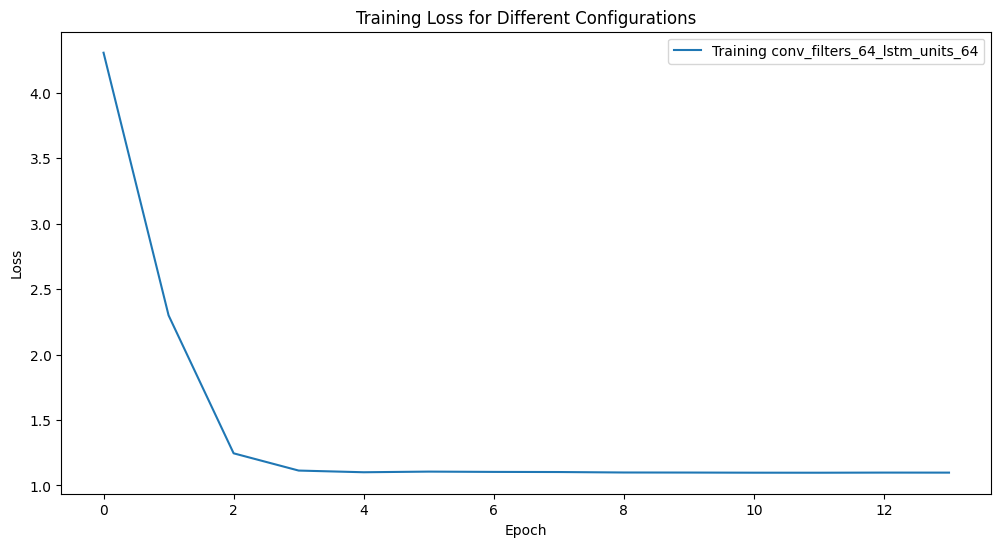

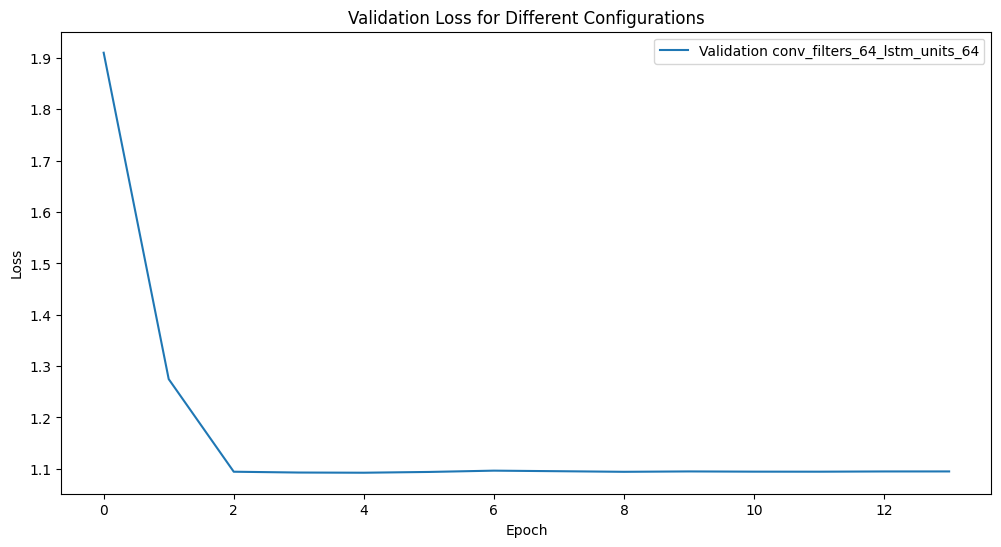

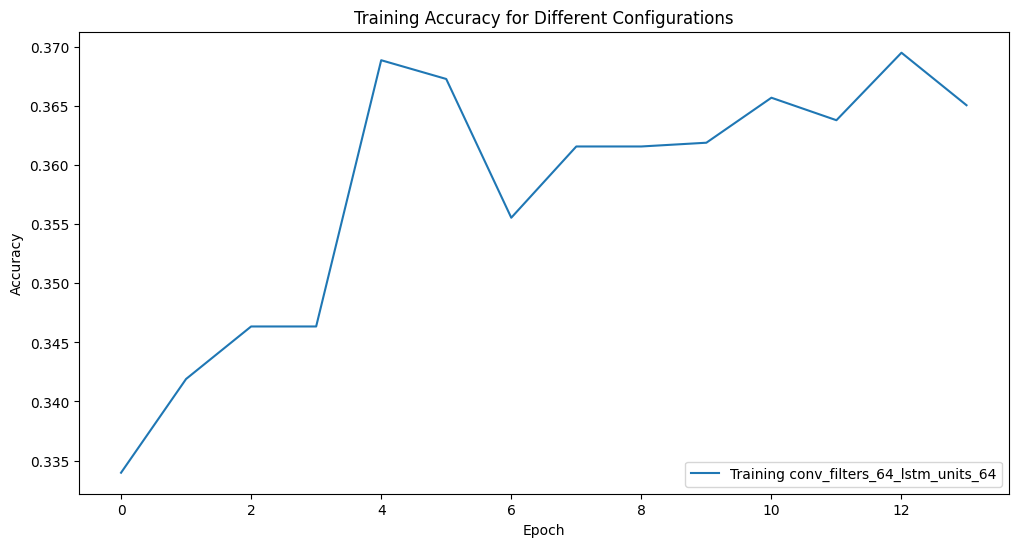

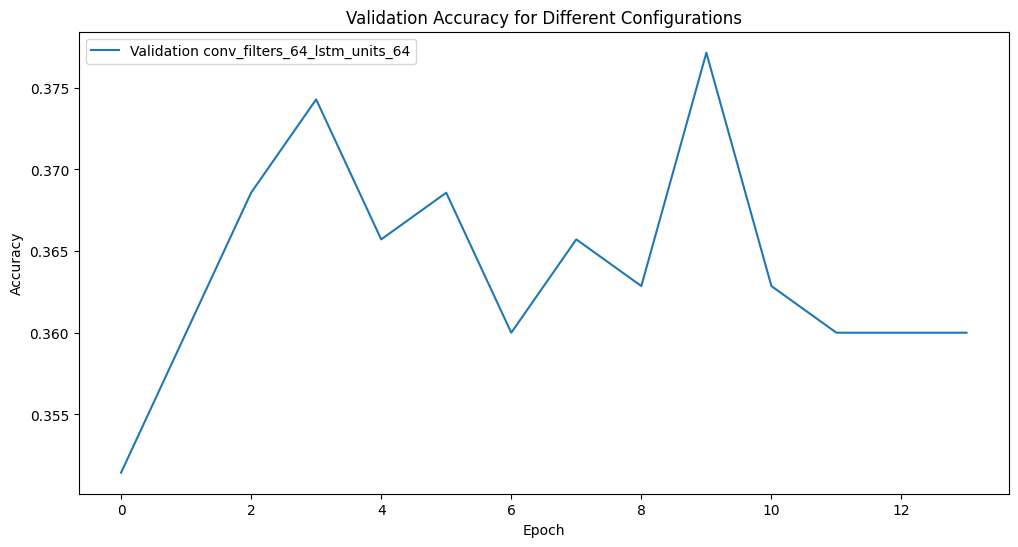

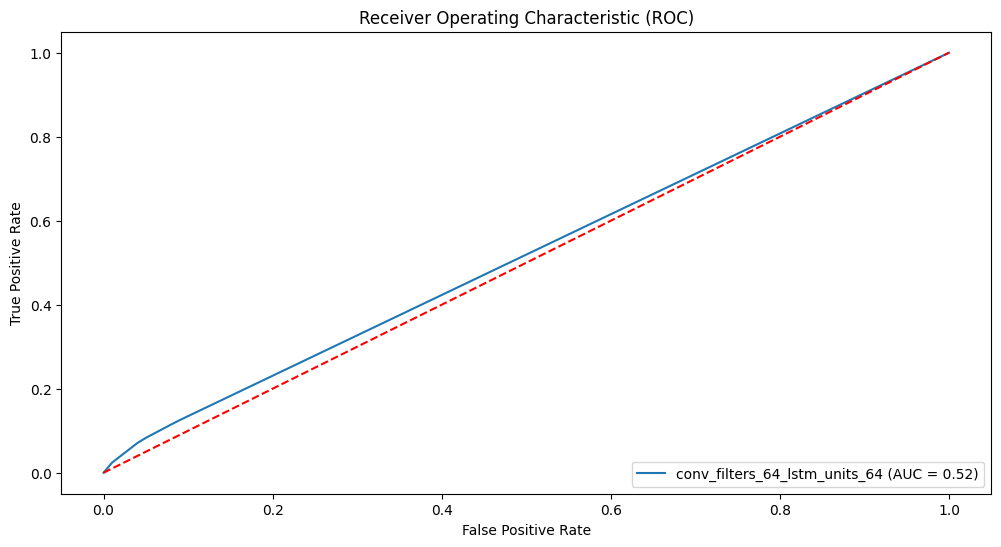

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get the length of the longest history record
max_len = max([len(history['loss']) for key in results_neurons for history in results_neurons[key]['histories']])

# Define a function to pad history records
def pad_history(history, max_len):
    padded_history = {}
    for key in history:
        padded_history[key] = history[key] + [history[key][-1]] * (max_len - len(history[key]))
    return padded_history

# Pad all history records
padded_results_neurons = {}
for key in results_neurons:
    padded_histories = [pad_history(history, max_len) for history in results_neurons[key]['histories']]
    padded_results_neurons[key] = {
        'histories': padded_histories,
        'mean_fpr': results_neurons[key]['mean_fpr'],
        'mean_tpr': results_neurons[key]['mean_tpr'],
        'mean_auc_curve': results_neurons[key]['mean_auc_curve']
    }

# Plot training loss
plt.figure(figsize=(12, 6))
for key in padded_results_neurons:
    mean_loss = np.mean([history['loss'] for history in padded_results_neurons[key]['histories']], axis=0)
    plt.plot(mean_loss, label=f'Training {key}')
plt.title('Training Loss for Different Configurations')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot validation loss
plt.figure(figsize=(12, 6))
for key in padded_results_neurons:
    mean_val_loss = np.mean([history['val_loss'] for history in padded_results_neurons[key]['histories']], axis=0)
    plt.plot(mean_val_loss, label=f'Validation {key}')
plt.title('Validation Loss for Different Configurations')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training accuracy
plt.figure(figsize=(12, 6))
for key in padded_results_neurons:
    mean_accuracy = np.mean([history['accuracy'] for history in padded_results_neurons[key]['histories']], axis=0)
    plt.plot(mean_accuracy, label=f'Training {key}')
plt.title('Training Accuracy for Different Configurations')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot validation accuracy
plt.figure(figsize=(12, 6))
for key in padded_results_neurons:
    mean_val_accuracy = np.mean([history['val_accuracy'] for history in padded_results_neurons[key]['histories']], axis=0)
    plt.plot(mean_val_accuracy, label=f'Validation {key}')
plt.title('Validation Accuracy for Different Configurations')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot ROC curve
plt.figure(figsize=(12, 6))
for key in padded_results_neurons:
    mean_fpr = padded_results_neurons[key]['mean_fpr']
    mean_tpr = padded_results_neurons[key]['mean_tpr']
    mean_auc = padded_results_neurons[key]['mean_auc_curve']
    plt.plot(mean_fpr, mean_tpr, label=f'{key} (AUC = {mean_auc:.2f})')

plt.plot([0, 1], [0, 1], color='r', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

### 5. Store the best weight

In [ ]:
save_dir = BASE_DIR / "train_weight"
save_dir.mkdir(parents=True, exist_ok=True)

conv_filters=64
lstm_units=64

model = create_model(input_shape, num_classes, conv_filters, lstm_units)
model.fit(data, targets, epochs=13, batch_size=8)
model.save(save_dir / f'violence_detection_model_conv_{conv_filters}_lstm_{lstm_units}v2.h5')

Epoch 1/13
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.3543 - loss: 1.1000
Epoch 2/13
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.4057 - loss: 1.0875
Epoch 3/13
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.4000 - loss: 1.0920
Epoch 4/13
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.4629 - loss: 1.0488
Epoch 5/13
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.5714 - loss: 0.9279
Epoch 6/13
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.5971 - loss: 0.8440
Epoch 7/13
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5857 - loss: 0.7795
Epoch 8/13
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.6200 - loss: 0.7557
Epoch 9/13
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.6743 - loss: 0.7090
Epoch 10/13
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.7257 - loss: 0.6665
Epoch 11/13
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.6886 - loss: 0.6623
Epoch 12/13
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: